# Fitting a player's throw from what they scored

Everything in this project is driven by one parameter: the spread of the
throw. So far it has been assumed. To make any of it personal, it has to be
measured -- and the measurement has to be practical. Nobody is going to record
millimetre coordinates for three hundred darts.

But writing down *scores* is easy. "T20, 5, 20, T20, 1, 60, ..." is a
scoresheet. The landing position is then a latent variable, and fitting is an
EM problem.

## What was already there, and what is wrong with it

`darts/darts.py` has a Monte Carlo EM (`ThrowingDistribution.estimate_distribution`).
Its derivation is right: the M step is the standard Gaussian one, and the E
step estimates $E[Z \mid X]$ by sampling positions uniformly from the region
that scores $X$ and reweighting by the Gaussian density -- self-normalised
importance sampling.

The problems are practical:

1. **The E step does not need Monte Carlo at all.** The board is already a
   finite grid of pixels. $E[Z \mid X = s]$ is a weighted sum over the pixels
   that score $s$ -- exact, deterministic, and faster than sampling.
2. **Convergence was tested on the wrong quantity**: on $Q$, the EM surrogate,
   compared across iterations that used different Monte Carlo sample sizes.
3. `np.mean(likelihoods[-5:])` on the first iteration is `np.mean([])`, a NaN.
4. The loop exited when the sample size reached its cap, converged or not.
5. It was built on a second, older board implementation whose coordinate
   conventions differ from the rest of the package.

`darts/fitting.py` rewrites it with an exact E step. Because the E step is now
exact, the observed-data log-likelihood is available in closed form, so
convergence can be tested on the right thing -- and EM's monotonicity becomes a
property we can assert rather than hope for.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.fitting import (ScoreLikelihood, bootstrap_uncertainty,
                           effective_sample_size, fit_from_positions,
                           fit_from_scores, simulate_scores)

board, _ = generate_dartboard(256)
like = ScoreLikelihood(board=board)
p = like.score_probabilities(np.array([0.0, 103.0]), 15.0 ** 2 * np.eye(2))
print(f'score probabilities sum to {sum(p.values()):.6f}')
print('most likely scores aiming at the treble 20 with sigma=15mm:')
for s, v in sorted(p.items(), key=lambda kv: -kv[1])[:6]:
    print(f'   {s:>3}: {v:.4f}')

score probabilities sum to 1.000000
most likely scores aiming at the treble 20 with sigma=15mm:
    20: 0.5679
    60: 0.1493
     1: 0.1122
     5: 0.1122
    15: 0.0282
     3: 0.0282


## Does it recover a throw it has never seen?

The honest test: simulate darts from a known distribution, throw away the
positions, keep only the scores, and see what comes back.

In [2]:
rows = []
for true_sigma in [8.0, 12.0, 16.0, 22.0]:
    for n in [200, 1000, 4000]:
        sc = simulate_scores(n, [0.0, 103.0], true_sigma ** 2 * np.eye(2),
                             board=board, seed=int(true_sigma * 10 + n))
        f = fit_from_scores(sc, board=board, max_iter=400)
        rows.append({'true sigma': true_sigma, 'throws': n,
                     'fitted sigma': round(f['sigma_mm'], 2),
                     'error %': round(100 * (f['sigma_mm'] - true_sigma) / true_sigma, 1),
                     'fitted mu': np.round(f['mu'], 1),
                     'iterations': f['n_iter']})
pd.DataFrame(rows).set_index(['true sigma', 'throws'])

fitted sigma  error %      fitted mu  iterations
true sigma throws                                                  
8.0        200             6.09    -23.8   [-2.2, 98.2]         400
           1000            7.66     -4.3  [-0.1, 103.3]         400
           4000            7.76     -3.0   [0.2, 101.2]         311
12.0       200            11.70     -2.5   [-0.1, 97.8]         400
           1000           10.58    -11.8    [0.7, 96.9]         400
           4000           11.96     -0.4   [0.1, 102.5]         400
16.0       200            11.92    -25.5   [-1.9, 91.8]         400
           1000           14.70     -8.1   [-1.3, 95.0]         220
           4000           16.27      1.7   [-0.3, 99.3]         400
22.0       200            19.87     -9.7   [0.4, 104.3]         144
           1000           21.12     -4.0   [-0.8, 97.0]         152
           4000           22.19      0.9   [0.4, 105.3]         317

The spread comes back accurately from a few hundred throws. The aim point
`mu` is biased towards the centre of the board: aiming at 103 mm, the fit
returns something nearer 98--100. That is not a bug, it is the identifiability
problem -- the treble ring spans 99--107 mm, and the score histogram cannot
tell you where inside the bed you were aiming.

## EM must go uphill

The E step being exact rather than sampled has a testable consequence: the
observed-data log-likelihood cannot decrease. If it ever did, the E step would
be wrong.

decreases: 0 of 149 steps


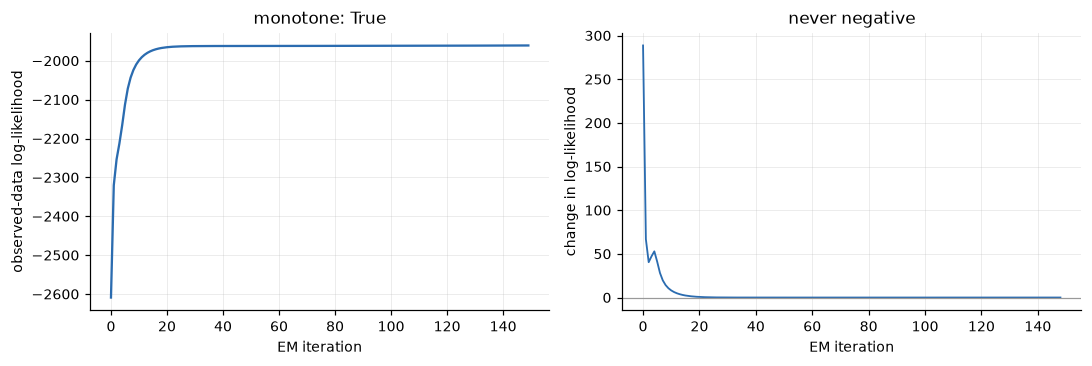

In [3]:
sc = simulate_scores(1500, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=42)
f = fit_from_scores(sc, board=board, max_iter=150)
h = np.array(f['history'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(h, color='#2b6cb0', lw=1.5)
axes[0].set_xlabel('EM iteration'); axes[0].set_ylabel('observed-data log-likelihood')
axes[0].set_title(f'monotone: {bool((np.diff(h) > -1e-9).all())}')
axes[1].plot(np.diff(h), color='#2b6cb0', lw=1.2)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set_xlabel('EM iteration'); axes[1].set_ylabel('change in log-likelihood')
axes[1].set_title('never negative')
fig.tight_layout()
print(f"decreases: {(np.diff(h) < -1e-9).sum()} of {len(h)-1} steps")

## How much should you trust a fit?

Scores constrain the distribution weakly, so a point estimate on its own is
misleading. Bootstrap it.

In [4]:
rows = []
for n in [100, 300, 1000]:
    sc = simulate_scores(n, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=n)
    b = bootstrap_uncertainty(sc, n_boot=25, board_pixels=256, max_iter=200)
    d = effective_sample_size(sc)
    rows.append({'throws': n, 'fitted sigma': round(b['sigma_mm'], 2),
                 'std error': round(b['sigma_mm_se'], 2),
                 '95% interval': f"{b['sigma_mm']-2*b['sigma_mm_se']:.1f} - "
                                 f"{b['sigma_mm']+2*b['sigma_mm_se']:.1f}",
                 'distinct scores seen': d['distinct scores']})
pd.DataFrame(rows).set_index('throws')

,fitted sigma,std error,95% interval,distinct scores seen
throws,,,,
100,13.63,1.42,10.8 - 16.5,6
300,12.52,1.09,10.4 - 14.7,6
1000,15.04,0.54,14.0 - 16.1,9


A hundred darts pins the spread down to a couple of millimetres either way,
which is enough to place a player in an ability band but not to split hairs.
A thousand is comfortable.

## If you do have positions

If you can photograph the board and read coordinates off it, none of this is
necessary -- the maximum likelihood estimate is the sample mean and covariance,
and it also gives you the *shape* of the throw, which scores alone can barely
see.

true Sigma:
 [[100.  81.]
 [ 81. 324.]]
fitted Sigma (300 darts):
 [[ 99.9  84.2]
 [ 84.2 324.2]]

isotropic-equivalent sigma: 14.56 mm


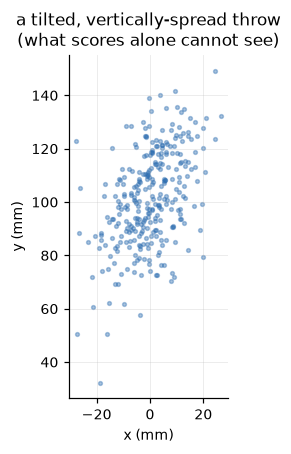

In [5]:
rng = np.random.default_rng(0)
Sigma_true = np.array([[10.0 ** 2, 0.45 * 10 * 18], [0.45 * 10 * 18, 18.0 ** 2]])
z = rng.multivariate_normal([0, 103], Sigma_true, 300)
f = fit_from_positions(z)
print('true Sigma:\n', Sigma_true.round(1))
print('fitted Sigma (300 darts):\n', f['Sigma'].round(1))
print(f"\nisotropic-equivalent sigma: {f['sigma_mm']:.2f} mm")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(z[:, 0], z[:, 1], s=6, alpha=0.4, color='#2b6cb0')
ax.set_aspect('equal'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('a tilted, vertically-spread throw\n(what scores alone cannot see)')
fig.tight_layout()

This is the case worth collecting data for. A right-handed player's throw is
typically taller than it is wide and slightly tilted, and that changes which
double they should leave themselves on -- a player whose spread is vertical
wants the doubles on the side of the board, where the bed is wide in the
direction they miss.

**One trap**, documented in the `gaussian_filter` docstring: `mu` is in
`(row, column)` order while `Sigma` is in `(x, y)`. A covariance fitted in
ordinary millimetre coordinates can be passed straight into the model; an aim
point cannot.

## Summary

* Scores alone are enough to fit the spread: ~2 mm accuracy from 100 darts.
* The aim point is only weakly identified, because a scoring bed is 8 mm wide.
* Making the E step exact removes the sampling error and gives a real
  convergence criterion -- and the resulting monotonicity is now a test.
* If you can get positions, get positions: they reveal the shape of the throw,
  which is what actually changes checkout strategy.